In [1]:
import tidy3d as td
import numpy as np
import tidy3d.web as web

import math
import os
from pathlib import Path

# import need be changed in some cases

# --- 1. Material Definitions ---
# Using fixed indices for 1550nm for simplicity

wdth_points = 20                                # number of width wv_points
num_modes = 2                                   # max number of modes to look up
core_thickness = 0.4

sweep_wavelength = np.linspace(1.550,1.5522,6) # Sweep on wavelengths
sweep_freq = td.C_0 / sweep_wavelength          # Sweep on Frequencies
sweep_width = np.linspace(0.6,1,wdth_points) #sweep on widths





In [2]:
def n_SiN (wavelength):

    return np.sqrt(1+(2.9144*wavelength**2)/(wavelength**2-0.1366**2)+(0.004873)/(wavelength**2-1.6606**2))


def n_SiO2 (wavelength):

    return np.sqrt(1+(1.1056*wavelength**2)/(wavelength**2-0.078**2)+(2.360*wavelength**2)/(wavelength**2-16.681**2)) + 0.002



print(f"Silicon Nitride: {n_SiN(1.55)}")
print(f"Silica: {n_SiO2(1.55)}")

Silicon Nitride: 1.9807799816328062
Silica: 1.4469404291704726


In [4]:


version_name = "SiN_sim"

project_dir = Path.cwd()  # directory where notebook is located
data_dir = project_dir / "data_STRp_SiN_mode_analysis"
data_dir.mkdir(parents=True, exist_ok=True)


def build_mode_simulation(
    core_width = np.array([0.600]),
    core_thickness = 0.400,
    wavelength = np.array([1550]),
    version_name = "SiN_Modal_analysis"
):

    base_path = f"data_STRp_SiN_mode_analysis_1550/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    # Materials
    core_n = n_SiN(wavelength)
    clad_n = n_SiO2(wavelength)

    # --- We define the simulation data array and simulation objects for the two different sweeps----

    sim_data_arr = [[[]],[[]]] # Simulation data for 220nm , TE and TM modes separated
    sim_arr = [[[]],[[]]]      # Simulation objects for 220nm and Width sweep, TE and TM modes separated
    estimate = 0

    for (pol_idx,pol_value) in enumerate(['TE','TM']):
        pol_folder = "{base_path}/pol"+pol_value
        os.makedirs(pol_folder, exist_ok=True)

        for (wave_idx,wave) in enumerate(wavelength):
            wave_folder = f"{pol_folder}/lam{int(wave*1000)}"
            os.makedirs(wave_folder, exist_ok=True)

            for (width_idx,width_values) in enumerate(core_width):

                filename = f"{wave_folder}/width_{int(width_values*1000)}.hdf5"


                core_medium = td.Medium(
                name = 'core_SiN_medium',
                permittivity = core_n[wave_idx]**2,
                )

                cladd_medium = td.Medium(
                name = 'cladd_SiO2_medium',
                permittivity = clad_n[wave_idx]**2,
                )


                waveguide = td.Structure(
                    geometry = td.Box(size = [td.inf, width_values, core_thickness]),
                    name = 'waveguide',
                    medium = core_medium
                )


                # --- Simulation domain ---
                sim_arr[pol_idx][wave_idx].append(td.ModeSimulation(
                    freqs = sweep_freq,
                    mode_spec = td.ModeSpec(target_neff = core_n[wave_idx], sort_spec = {'filter_reference' : 0, 'filter_order':'over', 'sort_order':'ascending', 'track_freq':'central'}, group_index_step = True, ),
                    size = [7, 7, 7],
                    grid_spec = td.GridSpec(grid_x = td.AutoGrid(min_steps_per_wvl = 11, ), grid_y = td.AutoGrid(min_steps_per_wvl = 11, ), grid_z = td.AutoGrid(min_steps_per_wvl = 11, ), wavelength = wave, ),
                    version = '2.10.1',
                    medium = cladd_medium,
                    sources = [],
                    monitors = [],
                    structures = [waveguide],
                    symmetry= [0,0,1] if pol_value == 'TE' else [0,0,-1],
                    plane= td.Box(center=[0,0,0], size=[7,7,0])
                ))


                if os.path.exists(filename):
                    print(f"Loading {filename}")
                    filename_path = Path(filename)
                    sim_data_arr[pol_idx][wave_idx].append(td.SimulationData.from_file(filename_path))

                else:
                    task_name = f"{version_name}_P"+pol_value+f"_lam{int(wave*1000)}_W{int(width_values*1000)}"
                    job = web.Job(simulation= sim_arr[pol_idx][wave_idx][width_idx], task_name=task_name)

                    # print(f"Running simulation: {task_name}")
                    # sim_data_arr[pol_idx][wave_idx].append(job.run())
                    # sim_data_arr[pol_idx][wave_idx][width_idx].to_file(filename)

                    Job = web.Job(simulation= sim_arr[pol_idx][wave_idx][width_idx], task_name="my_sim")

                    estimate += Job.estimate_cost()

            sim_data_arr[pol_idx][wave_idx].append([])
            sim_arr[pol_idx][wave_idx].append([])

    print(f"Estimated Maximum Cost: {estimate}")

    return sim_data_arr, sim_arr

a,b = build_mode_simulation(wavelength=sweep_wavelength,core_width=sweep_width,core_thickness=core_thickness,version_name=version_name)

18:00:44 -05 WARNING: updating ModeSimulation from 2.10.1 to 2.10.2             

18:00:45 -05 Created task 'my_sim' with resource_id                             
             'mos-a9502705-d12d-47c2-8815-de81183c9232' and task_type 'MODE'.

Output()

18:00:48 -05 Estimated FlexCredit cost: 0.008. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

             WARNING: updating ModeSimulation from 2.10.1 to 2.10.2             

...

             WARNING: updating ModeSimulation from 2.10.1 to 2.10.2             

             Created task 'my_sim' with resource_id                             
             'mos-4c6757d4-fd9e-4cd2-afeb-736a6deb3fc3' and task_type 'MODE'.

Output()

18:06:35 -05 Estimated FlexCredit cost: 0.008. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

IndexError: list index out of range

In [8]:
print(n_SiN(0.70))
print(n_SiO2(0.450))

2.0068948962333706
1.4642336699699325


In [9]:
"""
220nm width --> 450 nm wavelength
400nm width --> 700 nm wavelength

para infrarrojo cercano---> 500nm width

500um de largo de los multimode para los que no tienen PDK y y dejar 1000 um para los que si tienen PDK (infrarrojo)

"""

import gdsfactory as gf

gf.gpdk.PDK.activate()

def Strp_gds_SiN_visible(# core_material= 0,
                  # cladd_material= 0,
                  # neff= 0,
                  wg_width_strp = 0.420,
                  thickness = 0.22,
                  wg_multimode_width = 10,
                  taper_length = 5.0,
                  bend_radius = 20,
                  strip_length = 5.0,
                  strp_pos = (0,0),
                  layer = (733,727),):

    # //////  INICIO DE LA FUNCION
    # We define an sketch where we will place the components
    c = gf.Component()


    ############## Bend_IN ###################

    bend_in = gf.components.bend_euler(width=wg_width_strp,radius=bend_radius, angle= 45,layer = layer)
    ref_bend_in = c.add_ref(bend_in)

    ###########################################

    ############## Bend_OUT ###################

    bend_out = gf.components.bend_euler(width=wg_width_strp,radius=bend_radius,angle=-45,layer=layer)
    ref_bend_out = c.add_ref(bend_out)
    ref_bend_out.connect("o1", ref_bend_in.ports["o2"])

    ###########################################

    ############## MM In ########################

    s_bend_x_length =  ref_bend_out.ports["o2"].center[0]-ref_bend_in.ports["o1"].center[0]

    cross_MM_in_out = gf.cross_section.strip(
    width=wg_multimode_width,
    layer=layer
    )

    MM_in = gf.components.straight(length=(40 + 4200-2*strip_length-2*taper_length-s_bend_x_length)/2,cross_section=cross_MM_in_out)

    MM_in_ref = c.add_ref(MM_in)
    MM_in_ref.move((strp_pos[0],strp_pos[1]))

    ###############################################

    ############## Taper In ######################

    cross_taper_in = gf.cross_section.strip(
    width=wg_multimode_width,
    layer=layer
    )
    cross_taper_out = gf.cross_section.strip(
    width=wg_width_strp,
    layer=layer
    )

    taper_in = gf.components.taper_cross_section(length=taper_length,cross_section1=cross_taper_in,cross_section2=cross_taper_out)
    taper_in_ref = c.add_ref(taper_in)
    taper_in_ref.connect("o1", MM_in_ref.ports["o2"])

    ##############################################

    ############## Strip in SiN ###################

    cross_strip_wg = gf.cross_section.strip(
    width=wg_width_strp,
    layer=layer
    )

    STRP_SiN_in = gf.components.straight(length=strip_length,cross_section=cross_strip_wg)
    STRP_SiN_in_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_in_ref.connect("o1", taper_in_ref.ports["o2"])

    ###############################################

    ############## Bend_IN CONNECT ###################

    ref_bend_in.connect("o1", STRP_SiN_in_ref.ports["o2"])

    ###########################################

    ############## Bend_OUT CONNECT ###################

    ref_bend_out.connect("o1", ref_bend_in.ports["o2"])

    ###########################################


    ############## Strip out SiN ###################

    STRP_SiN_out_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_out_ref.connect("o1", ref_bend_out.ports["o2"])

    ###########################################


    ############## Taper out ###################

    taper_out = gf.components.taper_cross_section(length=taper_length,cross_section1=cross_taper_out,cross_section2=cross_taper_in)
    taper_out_ref = c.add_ref(taper_out)
    taper_out_ref.connect("o1", STRP_SiN_out_ref.ports["o2"])

    ###########################################

    ############## MM out ###################

    MM_out_ref = c.add_ref(MM_in)
    MM_out_ref.connect("o1", taper_out_ref.ports["o2"])

    ###############################################

    # Create text
    text = gf.components.text(
        text=f"Strip_V_W{wg_width_strp*1000:.1f}nm_Juanes",
        size=10,          # height in microns
        layer=layer
    )

    # Add to layout
    text_ref = c.add_ref(text)

    # Move it if needed
    text_ref.move((strp_pos[0] + 1700, strp_pos[1]+10))
    total_x_length_visible_strp = MM_out_ref.ports["o2"].center[0] - MM_in_ref.ports["o1"].center[0]  ## um
    total_y_length_visible_strp = bend_radius*2 + 10  ## um


    return c, total_x_length_visible_strp,total_y_length_visible_strp


def Strp_gds_SiN_infrared(# core_material= 0,
                      # cladd_material= 0,
                      # neff= 0,
                      wg_width_strp = 0.420,
                      thickness = 0.22,
                      wg_multimode_width = 10,
                      taper_length = 5.0,
                      bend_radius = 20,
                      strip_length = 5.0,
                      strp_pos = (0,0),
                      layer = (733,727),):

    # //////  INICIO DE LA FUNCION
    # We define an sketch where we will place the components
    c = gf.Component()


    ############## Bend_IN ###################

    bend_in = gf.components.bend_euler(width=wg_width_strp,radius=bend_radius, angle= 45,layer = layer)
    ref_bend_in = c.add_ref(bend_in)

    ###########################################

    ############## Bend_OUT ###################

    bend_out = gf.components.bend_euler(width=wg_width_strp,radius=bend_radius,angle=-45,layer=layer)
    ref_bend_out = c.add_ref(bend_out)
    ref_bend_out.connect("o1", ref_bend_in.ports["o2"])

    ###########################################


    s_bend_x_length =  ref_bend_out.ports["o2"].center[0]-ref_bend_in.ports["o1"].center[0]

    ############## Strip in SiN ###################

    cross_strip_wg = gf.cross_section.strip(
    width=wg_width_strp,
    layer=layer
    )

    strip_length_rest = ( 40 + 3200-s_bend_x_length)/2 # 1 um less for PDK

    STRP_SiN_in = gf.components.straight(length=strip_length_rest,cross_section=cross_strip_wg)
    STRP_SiN_in_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_in_ref.move((strp_pos[0] + (4200-2*strip_length_rest-s_bend_x_length)/2 ,strp_pos[1]))

    ###############################################

    ############## Bend_IN CONNECT ###################

    ref_bend_in.connect("o1", STRP_SiN_in_ref.ports["o2"])

    ###########################################

    ############## Bend_OUT CONNECT ###################

    ref_bend_out.connect("o1", ref_bend_in.ports["o2"])

    ###########################################

    ############## Strip out SiN ###################

    STRP_SiN_out_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_out_ref.connect("o1", ref_bend_out.ports["o2"])

    ###########################################

    # Create text
    text = gf.components.text(
        text=f"Strip_IR_W{wg_width_strp*1000:.1f}nm_Juanes",
        size=10,          # height in microns
        layer=layer
    )

    # Add to layout
    text_ref = c.add_ref(text)

    # Move it if needed
    text_ref.move((strp_pos[0] + 1700, strp_pos[1]+10))


    total_x_length_visible_strp = STRP_SiN_out_ref.ports["o2"].center[0] - STRP_SiN_in_ref.ports["o1"].center[0]  ## um
    total_y_length_visible_strp = STRP_SiN_out_ref.ports["o2"].center[1] - STRP_SiN_in_ref.ports["o1"].center[1]  ## um


    return c, total_x_length_visible_strp,total_y_length_visible_strp



def Strp_gds_SiN_visible_spiral(# core_material= 0,
                              # cladd_material= 0,
                              # neff= 0,
                              wg_width_strp = 0.420,
                              thickness = 0.22,
                              wg_multimode_width = 10,
                              taper_length = 5.0,
                              bend_radius = 20,
                              strip_length = 5.0,
                              strp_pos = (0,0),
                              layer = (733,727),):

    # //////  INICIO DE LA FUNCION
    # We define an sketch where we will place the components
    c = gf.Component()


    ############## Bend_IN ###################

    bend_in = gf.components.bend_euler(width=wg_width_strp,radius=bend_radius, angle= 45,layer = layer)
    ref_bend_in = c.add_ref(bend_in)

    ###########################################

    ############## Bend_OUT ###################

    bend_out = gf.components.bend_euler(width=wg_width_strp,radius=bend_radius,angle=-45,layer=layer)
    ref_bend_out = c.add_ref(bend_out)
    ref_bend_out.connect("o1", ref_bend_in.ports["o2"])

    ###########################################


    s_bend_x_length =  ref_bend_out.ports["o2"].center[0]-ref_bend_in.ports["o1"].center[0]

    ############## Strip in SiN ###################

    cross_strip_wg = gf.cross_section.strip(
    width=wg_width_strp,
    layer=layer
    )

    strip_length_rest = (3200-s_bend_x_length)/2 # 1 um less for PDK

    STRP_SiN_in = gf.components.straight(length=strip_length_rest,cross_section=cross_strip_wg)
    STRP_SiN_in_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_in_ref.move((strp_pos[0] + (40 + 4200-2*strip_length_rest-s_bend_x_length)/2 ,strp_pos[1]))

    ###############################################

    ############## Bend_IN CONNECT ###################

    ref_bend_in.connect("o1", STRP_SiN_in_ref.ports["o2"])

    ###########################################

    ############## Bend_OUT CONNECT ###################

    ref_bend_out.connect("o1", ref_bend_in.ports["o2"])

    ###########################################

    ############## Strip out SiN ###################

    STRP_SiN_out_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_out_ref.connect("o1", ref_bend_out.ports["o2"])

    ###########################################

    # Create text
    text = gf.components.text(
        text=f"Strip_IR_W{wg_width_strp*1000:.1f}nm_Juanes",
        size=10,          # height in microns
        layer=layer
    )

    # Add to layout
    text_ref = c.add_ref(text)

    # Move it if needed
    text_ref.move((strp_pos[0] + 1700, strp_pos[1]+10))


    total_x_length_visible_strp = STRP_SiN_out_ref.ports["o2"].center[0] - STRP_SiN_in_ref.ports["o1"].center[0]  ## um
    total_y_length_visible_strp = STRP_SiN_out_ref.ports["o2"].center[1] - STRP_SiN_in_ref.ports["o1"].center[1]  ## um


    return c, total_x_length_visible_strp,total_y_length_visible_strp



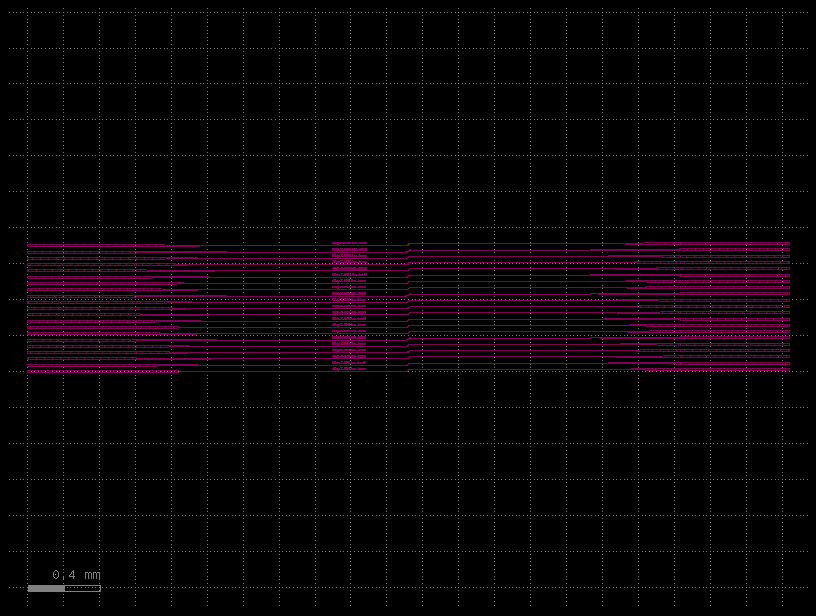

In [10]:
STR_scketch = gf.Component()

x_pos = 0
y_pos = 0

# Strip waveguides for visible
for width in np.linspace(0.220,0.400,10):
    STRP = Strp_gds_SiN_visible(wg_width_strp=width,strip_length=2000/2,taper_length=500, bend_radius= 20 ,layer=(733,727), strp_pos=(x_pos, y_pos))
    STR_scketch.add_ref(STRP[0])
    y_pos += 35


# Strip waveguides for infrared 700-1000 nm, PDK available

for width in np.linspace(0.5,1.5,11):
    STRP = Strp_gds_SiN_visible(wg_width_strp=width,strip_length=2000/2, taper_length=500,bend_radius= 20 ,layer=(733,727), strp_pos=(x_pos, y_pos))
    STR_scketch.add_ref(STRP[0])
    y_pos += 35


STR_scketch.draw_ports()
STR_scketch.plot()
STR_scketch.write("Strp_gds_V_IR_Juanes.gds")
STR_scketch.show()